<a href="https://colab.research.google.com/github/kelvintawe12/SDG-Indicator-Text/blob/main/SDG3_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SDG 3 Indicator Multi-Label Text Classification
**Group Assignment 2** — Complete pipeline: EDA → Preprocessing → Feature Engineering → Experiments → Evaluation → Inference


### Sections
1. Setup & Installs
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Preprocessing Pipeline
5. Feature Engineering
6. Experiments (8 total)
7. Results Summary & Model Comparison
8. Inference on Test Set


---
## Section 1 — Setup & Installs


In [1]:
# Install required libraries (only needed once per Colab session)
!pip install -q scikit-multilearn imbalanced-learn sentence-transformers seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 2.7 MB/s eta 0:00:00


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import hamming_loss, classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# scikit-multilearn
from skmultilearn.model_selection import iterative_train_test_split

# Sentence Transformers
from sentence_transformers import SentenceTransformer

# Scipy
from scipy.sparse import hstack, issparse

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Section 2 — Load Data


In [52]:

# ── Load datasets


TRAIN_PATH = 'Devex_train.csv'
TEST_PATH  = 'Devex_test_questions.csv'
def read_csv_safe(path):
    # Define a comprehensive list of values to be interpreted as NaN
    na_vals = ['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan', \
               '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'n/a', 'nan', 'null']
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            return pd.read_csv(path, encoding=enc, na_values=na_vals, keep_default_na=True)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'Could not read {path} with any common encoding')

train_df = read_csv_safe(TRAIN_PATH)
test_df  = read_csv_safe(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
print()
print('Train columns:', train_df.columns.tolist())
print('Test  columns:', test_df.columns.tolist())

Train shape: (2995, 15)
Test  shape: (998, 3)

Train columns: ['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']
Test  columns: ['Unique ID', 'Type', 'Text']


In [53]:
# Preview the training data
train_df.head(3)

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# ── Identify the text column and label columns

TEXT_COL = 'Text'
LABEL_COLS = [f'Label {i}' for i in range(1, 11)]

# Convert identified label columns to binary (1 if present, 0 if missing/empty)
for col in LABEL_COLS:
    # This function will handle explicit NaN, None, empty strings, and common string representations of missing data
    def is_label_present(val):
        # Explicitly check for actual NaN or None
        if pd.isna(val) or val is None:
            return 0
        # If it's a string, check for empty string after strip, or common "missing" strings
        if isinstance(val, str):
            val_lower = val.strip().lower()
            if val_lower == '' or val_lower in ['nan', 'none', 'null', 'n/a', '-']:
                return 0
        # Otherwise, consider it a present label
        return 1
    train_df[col] = train_df[col].apply(is_label_present)

print(f'Text column  : {TEXT_COL}')
print(f'Label columns ({len(LABEL_COLS)}): {LABEL_COLS[:5]} ...')
print()
print('Sample text:')
print(train_df[TEXT_COL].iloc[0][:300])

Text column  : Text
Label columns (10): ['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5'] ...

Sample text:
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not 


In [55]:
# Basic data quality checks
print('Missing values in train:')
print(train_df.isnull().sum())
print()
print('Missing values in test:')
print(test_df.isnull().sum())

# Fill any missing text with empty string
train_df[TEXT_COL] = train_df[TEXT_COL].fillna('')
test_df[TEXT_COL]  = test_df[TEXT_COL].fillna('')

print('\nMissing values handled.')

Missing values in train:
Unique ID       0
Type            0
Text            0
Label 1         0
Label 2         0
Label 3         0
Label 4         0
Label 5         0
Label 6         0
Label 7         0
Label 8         0
Label 9         0
Label 10        0
Label 11     2995
Label 12     2995
dtype: int64

Missing values in test:
Unique ID    0
Type         0
Text         0
dtype: int64

Missing values handled.


---
## Section 3 — Exploratory Data Analysis (EDA)


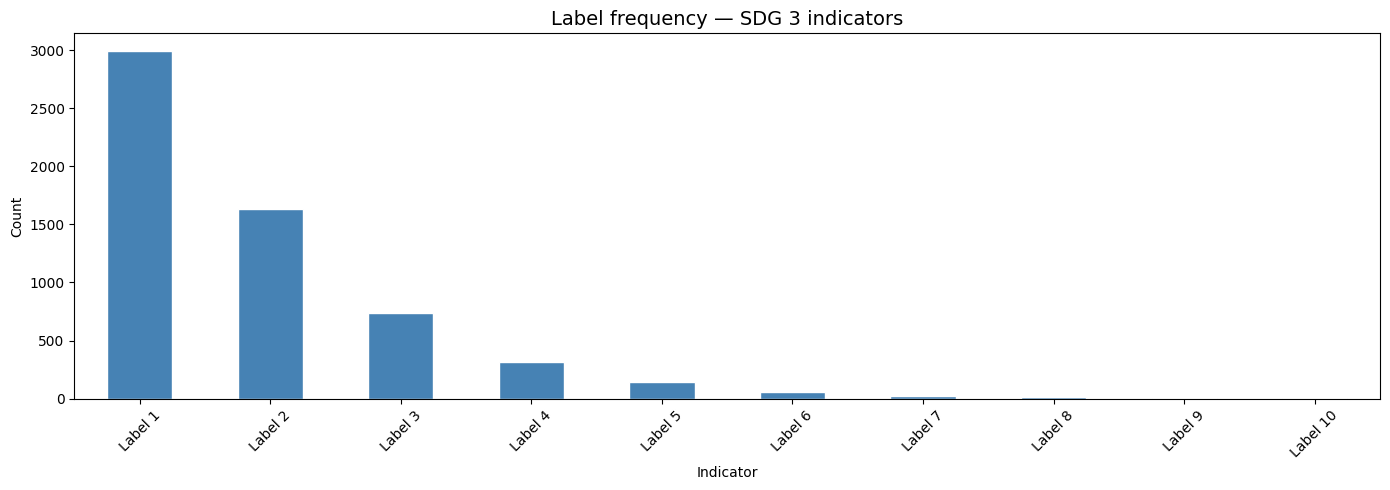

Most common labels:
Label 1    2995
Label 2    1635
Label 3     738
Label 4     312
Label 5     142
dtype: int64

Least common labels:
Label 6     59
Label 7     21
Label 8     10
Label 9      4
Label 10     2
dtype: int64


In [56]:
# ── 3.1 Label frequency distribution ──────────────────────────────────────────
label_counts = train_df[LABEL_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
label_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Label frequency — SDG 3 indicators', fontsize=14)
ax.set_xlabel('Indicator')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_label_frequency.png', dpi=150)
plt.show()

print('Most common labels:')
print(label_counts.head(5))
print('\nLeast common labels:')
print(label_counts.tail(5))

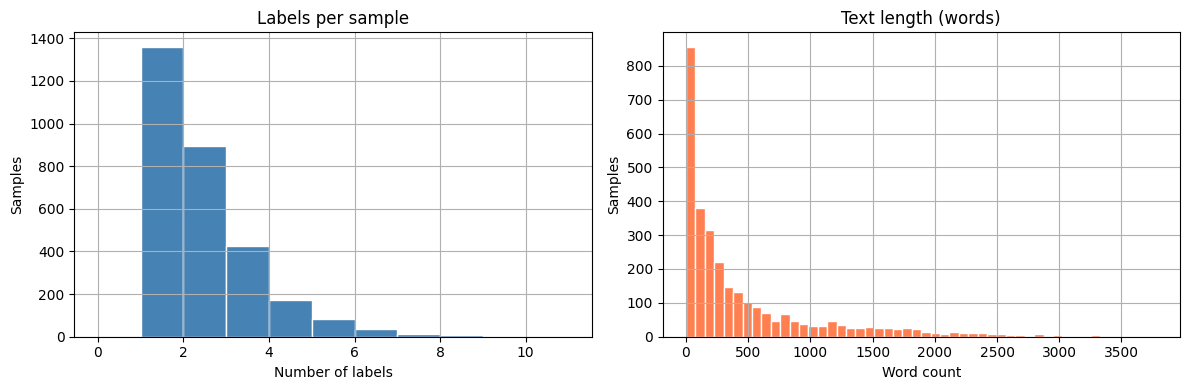

Avg labels per sample : 1.98
Max labels per sample : 10
Samples with 0 labels : 0
Avg text length (words): 478


In [57]:
# ── 3.2 Labels per sample distribution ─────────────────────────────────────────
labels_per_sample = train_df[LABEL_COLS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cast the max value to int as range() expects integers
labels_per_sample.hist(bins=range(0, int(labels_per_sample.max())+2), ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Labels per sample')
axes[0].set_xlabel('Number of labels')
axes[0].set_ylabel('Samples')

# Text length distribution
text_lengths = train_df[TEXT_COL].str.split().str.len()
text_lengths.hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Text length (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Samples')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

print(f'Avg labels per sample : {labels_per_sample.mean():.2f}')
print(f'Max labels per sample : {labels_per_sample.max()}')
print(f'Samples with 0 labels : {(labels_per_sample == 0).sum()}')
print(f'Avg text length (words): {text_lengths.mean():.0f}')

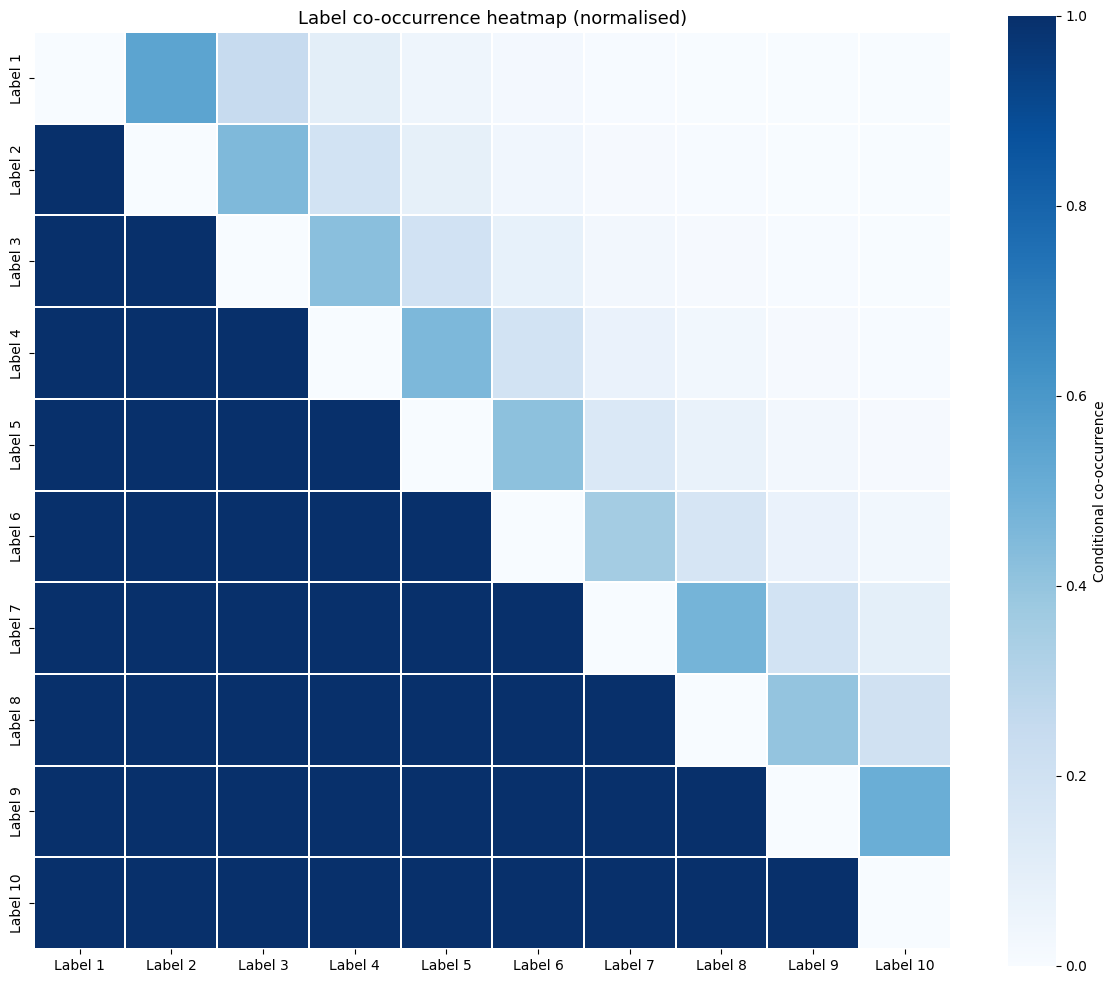

Baseline Hamming Loss (all zeros): 0.1976
This is the floor — any model must beat this.


In [58]:
# ── 3.3 Label co-occurrence heatmap ───────────────────────────────────────────
label_matrix = train_df[LABEL_COLS].values
co_occur = label_matrix.T @ label_matrix  # shape: (n_labels, n_labels)
co_occur_df = pd.DataFrame(co_occur, index=LABEL_COLS, columns=LABEL_COLS)

# Normalise by diagonal (self-count) to get conditional probability
diag = np.diag(co_occur).astype(float)
diag[diag == 0] = 1
co_occur_norm = co_occur / diag[:, None]
co_occur_norm_df = pd.DataFrame(co_occur_norm, index=LABEL_COLS, columns=LABEL_COLS)
np.fill_diagonal(co_occur_norm_df.values, 0)  # hide self-co-occurrence

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(co_occur_norm_df, cmap='Blues', ax=ax, square=True,
            linewidths=0.3, cbar_kws={'label': 'Conditional co-occurrence'})
ax.set_title('Label co-occurrence heatmap (normalised)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_cooccurrence.png', dpi=150)
plt.show()

# Baseline Hamming Loss (always predict 0)
y_all = train_df[LABEL_COLS].values
zero_pred = np.zeros_like(y_all)
baseline_hl = hamming_loss(y_all, zero_pred)
print(f'Baseline Hamming Loss (all zeros): {baseline_hl:.4f}')
print('This is the floor — any model must beat this.')

---
## Section 4 — Preprocessing Pipeline


In [59]:
# ── Preprocessing function ─────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# SDG-domain stopwords to keep (they carry meaning in this domain)
KEEP_WORDS = {'health', 'disease', 'mortality', 'maternal', 'child', 'mental',
              'nutrition', 'water', 'sanitation', 'tobacco', 'vaccine', 'hiv',
              'aids', 'malaria', 'tuberculosis', 'drug', 'sexual', 'reproductive'}
stop_words -= KEEP_WORDS

def preprocess_text(text, lemmatize=True, remove_stopwords=True):
    """Clean and normalise a single text string."""
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenise
    tokens = word_tokenize(text)
    # Remove stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Lemmatise
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply to train and test
print('Preprocessing train texts...')
train_df['text_clean'] = train_df[TEXT_COL].apply(preprocess_text)
print('Preprocessing test texts...')
test_df['text_clean']  = test_df[TEXT_COL].apply(preprocess_text)

print('Done.')
print('\nSample original:')
print(train_df[TEXT_COL].iloc[0][:200])
print('\nSample cleaned:')
print(train_df['text_clean'].iloc[0][:200])

Preprocessing train texts...
Preprocessing test texts...
Done.

Sample original:
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Devel

Sample cleaned:
center biomedical research excellence cobre phase iii transitional center funding opportunity description institutional development award idea program endeavor stimulate research institution state tra


In [60]:
# ── Train / validation split (stratified for multi-label) ─────────────────────
from scipy.sparse import csr_matrix

X_text = train_df['text_clean'].values
Y      = train_df[LABEL_COLS].values.astype(int)

# iterative_train_test_split requires dense arrays as index arrays
indices = np.arange(len(X_text)).reshape(-1, 1)
idx_train, _, idx_val, _ = iterative_train_test_split(
    indices, Y, test_size=0.2
)
idx_train = idx_train.ravel()
idx_val   = idx_val.ravel()

X_train_text = X_text[idx_train]
X_val_text   = X_text[idx_val]
Y_train      = Y[idx_train]
Y_val        = Y[idx_val]
X_test_text  = test_df['text_clean'].values

print(f'Train size : {len(X_train_text)}')
print(f'Val   size : {len(X_val_text)}')
print(f'Test  size : {len(X_test_text)}')

# Helper to evaluate any prediction
def evaluate(y_true, y_pred, name='Model'):
    hl  = hamming_loss(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro',  zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'{name:40s}  HL={hl:.4f}  F1-macro={f1m:.4f}  F1-weighted={f1w:.4f}')
    return {'name': name, 'hamming_loss': hl, 'f1_macro': f1m, 'f1_weighted': f1w}

results = []  # collect all experiment results

Train size : 2396
Val   size : 599
Test  size : 998


---
## Section 5 — Feature Engineering


In [61]:
# ── 5.1 TF-IDF features ────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True,
    min_df=2
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print('TF-IDF feature matrix shape:', X_train_tfidf.shape)

TF-IDF feature matrix shape: (2396, 30000)


In [62]:
# ── 5.2 Sentence-BERT embeddings (used in Experiments 4, 7, 8)


print('Loading sentence-transformers model...')
sbert = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding train texts...')
X_train_sbert = sbert.encode(X_train_text.tolist(), batch_size=64,
                              show_progress_bar=True, convert_to_numpy=True)
print('Encoding val texts...')
X_val_sbert   = sbert.encode(X_val_text.tolist(), batch_size=64,
                              show_progress_bar=True, convert_to_numpy=True)
print('Encoding test texts...')
X_test_sbert  = sbert.encode(X_test_text.tolist(), batch_size=64,
                              show_progress_bar=True, convert_to_numpy=True)

print('\nSBERT embedding shape:', X_train_sbert.shape)

Loading sentence-transformers model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train texts...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Encoding val texts...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


SBERT embedding shape: (2396, 384)


---
## Section 6 — Experiments
Each cell is one experiment. Run them in order.


In [63]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1 — TF-IDF + Logistic Regression (BASELINE)
# Why: Establish a simple sparse-feature baseline.
# ══════════════════════════════════════════════════════════════════════════════
clf_exp1 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    n_jobs=-1
)
clf_exp1.fit(X_train_tfidf, Y_train)
pred_exp1 = clf_exp1.predict(X_val_tfidf)

res = evaluate(Y_val, pred_exp1, 'Exp 1: TF-IDF + Logistic Regression')
results.append(res)

Exp 1: TF-IDF + Logistic Regression       HL=0.0760  F1-macro=0.1697  F1-weighted=0.6864


In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2 — TF-IDF + Random Forest
# Why: Test a tree-based ensemble on the same sparse features as Exp 1.
#      Does non-linearity help over logistic regression?
# ══════════════════════════════════════════════════════════════════════════════
clf_exp2 = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
)
clf_exp2.fit(X_train_tfidf, Y_train)
pred_exp2 = clf_exp2.predict(X_val_tfidf)

res = evaluate(Y_val, pred_exp2, 'Exp 2: TF-IDF + Random Forest')
results.append(res)

Exp 2: TF-IDF + Random Forest             HL=0.0681  F1-macro=0.2489  F1-weighted=0.7723


In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3 — TF-IDF + LinearSVC
# Why: LinearSVC is often strong on high-dimensional sparse text. Compare to LR.
# ══════════════════════════════════════════════════════════════════════════════
clf_exp3 = OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=0.5, random_state=RANDOM_STATE),
    n_jobs=-1
)
clf_exp3.fit(X_train_tfidf, Y_train)
pred_exp3 = clf_exp3.predict(X_val_tfidf)

res = evaluate(Y_val, pred_exp3, 'Exp 3: TF-IDF + LinearSVC')
results.append(res)

Exp 3: TF-IDF + LinearSVC                 HL=0.0805  F1-macro=0.1624  F1-weighted=0.6547


In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4 — Sentence-BERT embeddings + Logistic Regression
# Why: Dense contextual embeddings vs sparse TF-IDF — does context help?
# ══════════════════════════════════════════════════════════════════════════════
clf_exp4 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    n_jobs=-1
)
clf_exp4.fit(X_train_sbert, Y_train)
pred_exp4 = clf_exp4.predict(X_val_sbert)

res = evaluate(Y_val, pred_exp4, 'Exp 4: SBERT + Logistic Regression')
results.append(res)

Exp 4: SBERT + Logistic Regression        HL=0.0756  F1-macro=0.1819  F1-weighted=0.7052


In [67]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5 — TF-IDF + LR with class_weight balancing
# Why: EDA showed class imbalance. Does weighting rare labels improve performance?
# ══════════════════════════════════════════════════════════════════════════════
clf_exp5 = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced',
                       random_state=RANDOM_STATE),
    n_jobs=-1
)
clf_exp5.fit(X_train_tfidf, Y_train)
pred_exp5 = clf_exp5.predict(X_val_tfidf)

res = evaluate(Y_val, pred_exp5, 'Exp 5: TF-IDF + LR (class balanced)')
results.append(res)

Exp 5: TF-IDF + LR (class balanced)       HL=0.0815  F1-macro=0.3037  F1-weighted=0.7322


In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6 — TF-IDF + LR with per-label threshold tuning
# Why: Default threshold 0.5 may not be optimal for each label. Tune per label
#      on validation set to minimise Hamming Loss per label.
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.calibration import CalibratedClassifierCV

# Use Exp 1 model and get probability estimates
clf_cal = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    ),
    n_jobs=-1
)
clf_cal.fit(X_train_tfidf, Y_train)
proba_val = clf_cal.predict_proba(X_val_tfidf)

# Find optimal threshold per label
thresholds = []
for i in range(Y_val.shape[1]):
    best_t, best_hl = 0.5, float('inf')
    for t in np.arange(0.1, 0.9, 0.05):
        pred_i = (proba_val[:, i] >= t).astype(int)
        hl_i   = hamming_loss(Y_val[:, i], pred_i)
        if hl_i < best_hl:
            best_hl, best_t = hl_i, t
    thresholds.append(best_t)

pred_exp6 = (proba_val >= np.array(thresholds)).astype(int)

res = evaluate(Y_val, pred_exp6, 'Exp 6: TF-IDF + LR + per-label threshold')
results.append(res)
print(f'\nMean optimal threshold: {np.mean(thresholds):.3f}')
print(f'Min threshold: {min(thresholds):.3f}  Max: {max(thresholds):.3f}')

Exp 6: TF-IDF + LR + per-label threshold  HL=0.0659  F1-macro=0.3328  F1-weighted=0.7719

Mean optimal threshold: 0.310
Min threshold: 0.100  Max: 0.700


In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7 — SBERT + LR + per-label threshold tuning
# Why: Combine best embedding (SBERT from Exp 4) with best threshold strategy
#      (Exp 6). Does SBERT + tuned thresholds beat TF-IDF + tuned thresholds?
# ══════════════════════════════════════════════════════════════════════════════
clf_exp7 = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    ),
    n_jobs=-1
)
clf_exp7.fit(X_train_sbert, Y_train)
proba_val_sbert = clf_exp7.predict_proba(X_val_sbert)

# Per-label threshold tuning on SBERT probabilities
thresholds_sbert = []
for i in range(Y_val.shape[1]):
    best_t, best_hl = 0.5, float('inf')
    for t in np.arange(0.1, 0.9, 0.05):
        pred_i = (proba_val_sbert[:, i] >= t).astype(int)
        hl_i   = hamming_loss(Y_val[:, i], pred_i)
        if hl_i < best_hl:
            best_hl, best_t = hl_i, t
    thresholds_sbert.append(best_t)

pred_exp7 = (proba_val_sbert >= np.array(thresholds_sbert)).astype(int)

res = evaluate(Y_val, pred_exp7, 'Exp 7: SBERT + LR + per-label threshold')
results.append(res)

Exp 7: SBERT + LR + per-label threshold   HL=0.0694  F1-macro=0.2711  F1-weighted=0.7542


In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8 — Hybrid features: TF-IDF + SBERT concatenated
# Why: TF-IDF captures vocabulary/domain terms; SBERT captures semantics.
#      Combining both may give the richest representation.
# ══════════════════════════════════════════════════════════════════════════════
from scipy.sparse import hstack as sp_hstack
from scipy.sparse import csr_matrix

X_train_hybrid = sp_hstack([X_train_tfidf, csr_matrix(X_train_sbert)])
X_val_hybrid   = sp_hstack([X_val_tfidf,   csr_matrix(X_val_sbert)])
X_test_hybrid  = sp_hstack([X_test_tfidf,  csr_matrix(X_test_sbert)])

clf_exp8_cal = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    ),
    n_jobs=-1
)
clf_exp8_cal.fit(X_train_hybrid, Y_train)
proba_val_hybrid = clf_exp8_cal.predict_proba(X_val_hybrid)

# Per-label threshold tuning
thresholds_hybrid = []
for i in range(Y_val.shape[1]):
    best_t, best_hl = 0.5, float('inf')
    for t in np.arange(0.1, 0.9, 0.05):
        pred_i = (proba_val_hybrid[:, i] >= t).astype(int)
        hl_i   = hamming_loss(Y_val[:, i], pred_i)
        if hl_i < best_hl:
            best_hl, best_t = hl_i, t
    thresholds_hybrid.append(best_t)

pred_exp8 = (proba_val_hybrid >= np.array(thresholds_hybrid)).astype(int)

res = evaluate(Y_val, pred_exp8, 'Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold')
results.append(res)

Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold  HL=0.0651  F1-macro=0.3197  F1-weighted=0.7722


---
## Section 7 — Results Summary & Model Comparison


In [71]:
# ── 7.1 Experiment comparison table ───────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('hamming_loss')
results_df.index = range(1, len(results_df)+1)

# Highlight best row
best_idx = results_df['hamming_loss'].idxmin()
print('Experiment comparison (sorted by Hamming Loss):')
print(results_df.to_string(index=True))
print(f'\nBest model: {results_df.loc[best_idx, "name"]}')
print(f'Best Hamming Loss: {results_df.loc[best_idx, "hamming_loss"]:.4f}')

Experiment comparison (sorted by Hamming Loss):
                                                 name  hamming_loss  f1_macro  f1_weighted
1  Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold      0.065109  0.319653     0.772216
2            Exp 6: TF-IDF + LR + per-label threshold      0.065943  0.332760     0.771899
3                       Exp 2: TF-IDF + Random Forest      0.068114  0.248887     0.772326
4             Exp 7: SBERT + LR + per-label threshold      0.069449  0.271110     0.754228
5                  Exp 4: SBERT + Logistic Regression      0.075626  0.181900     0.705151
6                 Exp 1: TF-IDF + Logistic Regression      0.075960  0.169742     0.686355
7                           Exp 3: TF-IDF + LinearSVC      0.080467  0.162395     0.654677
8                 Exp 5: TF-IDF + LR (class balanced)      0.081469  0.303666     0.732244

Best model: Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold
Best Hamming Loss: 0.0651


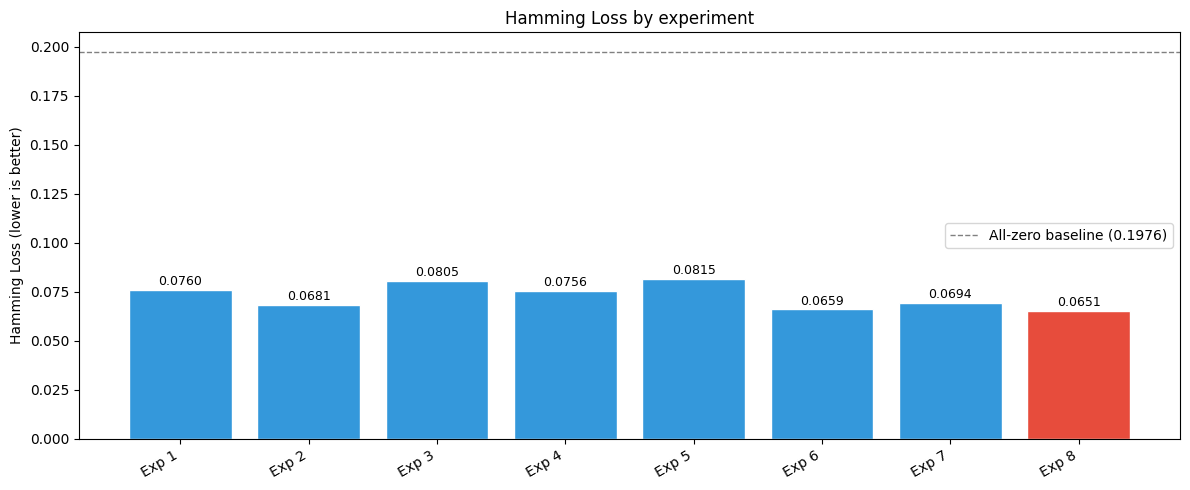

In [72]:
# ── 7.2 Bar chart: Hamming Loss per experiment ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
short_names = [r['name'].split(':')[0] for r in results]
hl_values   = [r['hamming_loss'] for r in results]

colors = ['#e74c3c' if v == min(hl_values) else '#3498db' for v in hl_values]
bars = ax.bar(range(len(results)), hl_values, color=colors, edgecolor='white')
ax.set_xticks(range(len(results)))
ax.set_xticklabels(short_names, rotation=30, ha='right')
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title('Hamming Loss by experiment')
ax.axhline(baseline_hl, color='gray', linestyle='--', linewidth=1, label=f'All-zero baseline ({baseline_hl:.4f})')
ax.legend()

for bar, val in zip(bars, hl_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results_hamming_comparison.png', dpi=150)
plt.show()

Best experiment: Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold


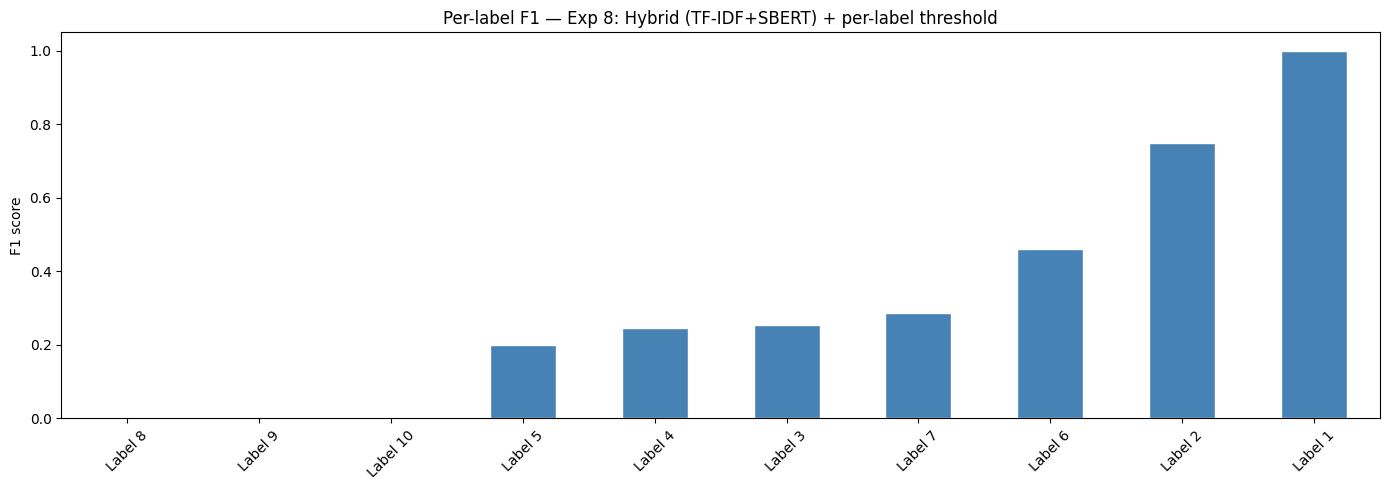

Lowest F1 labels (hardest to predict):
Label 8     0.000000
Label 9     0.000000
Label 10    0.000000
Label 5     0.200000
Label 4     0.246575
dtype: float64


In [73]:
# ── 7.3 Per-label F1 for best model ───────────────────────────────────────────
# Identify best experiment's prediction
best_name = results_df.iloc[0]['name']
print(f'Best experiment: {best_name}')

# Map name to prediction array (adjust if you add more experiments)
pred_map = {
    results[0]['name']: pred_exp1,
    results[1]['name']: pred_exp2,
    results[2]['name']: pred_exp3,
    results[3]['name']: pred_exp4,
    results[4]['name']: pred_exp5,
    results[5]['name']: pred_exp6,
    results[6]['name']: pred_exp7,
    results[7]['name']: pred_exp8,
}
best_pred = pred_map[best_name]

# Per-label F1
f1_per_label = f1_score(Y_val, best_pred, average=None, zero_division=0)
f1_label_df  = pd.Series(f1_per_label, index=LABEL_COLS).sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
f1_label_df.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Per-label F1 — {best_name}', fontsize=12)
ax.set_ylabel('F1 score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('results_per_label_f1.png', dpi=150)
plt.show()

print('Lowest F1 labels (hardest to predict):')
print(f1_label_df.head(5))

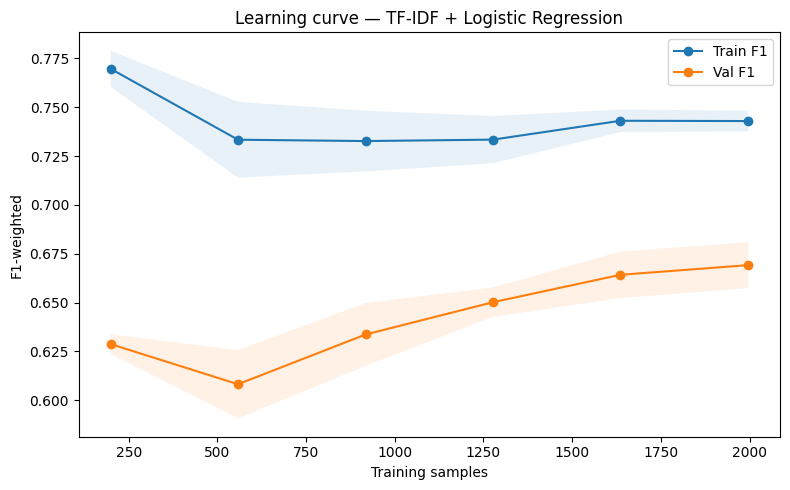

In [74]:
# ── 7.4 Learning curve for best TF-IDF model (Exp 1 or 6) ─────────────────────
from sklearn.model_selection import learning_curve

lc_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    n_jobs=-1
)

# Use full training features (TF-IDF on all train)
tfidf_lc = TfidfVectorizer(ngram_range=(1,2), max_features=30000,
                            sublinear_tf=True, min_df=2)
X_full_tfidf = tfidf_lc.fit_transform(X_text)

train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_full_tfidf, Y,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring='f1_weighted',
    cv=3, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train F1')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Val F1')
ax.fill_between(train_sizes,
                train_scores.mean(1)-train_scores.std(1),
                train_scores.mean(1)+train_scores.std(1), alpha=0.1)
ax.fill_between(train_sizes,
                val_scores.mean(1)-val_scores.std(1),
                val_scores.mean(1)+val_scores.std(1), alpha=0.1)
ax.set_xlabel('Training samples')
ax.set_ylabel('F1-weighted')
ax.set_title('Learning curve — TF-IDF + Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('results_learning_curve.png', dpi=150)
plt.show()

---
## Section 8 — Inference on Test Set
Apply the best model to the test set and save predictions.


In [75]:
# ── Retrain best model on FULL training data (train + val) ────────────────────
# We held out val only for evaluation. For final predictions, use all labelled data.

print('Retraining best model on full training data...')

# ── Choose which feature set to use based on best experiment ──────────────────
# Edit BEST_FEATURES to 'tfidf', 'sbert', or 'hybrid' based on your results
BEST_FEATURES = 'hybrid'

# Rebuild features on full data
tfidf_final = TfidfVectorizer(ngram_range=(1,2), max_features=30000,
                               sublinear_tf=True, min_df=2)
X_full_tfidf_final = tfidf_final.fit_transform(X_text)
X_test_tfidf_final = tfidf_final.transform(X_test_text)

# SBERT on full data (already encoded above; re-encode full set)
print('Encoding full train set with SBERT...')
X_full_sbert_final = sbert.encode(X_text.tolist(), batch_size=64,
                                   show_progress_bar=True, convert_to_numpy=True)

if BEST_FEATURES == 'tfidf':
    X_train_final = X_full_tfidf_final
    X_test_final  = X_test_tfidf_final
elif BEST_FEATURES == 'sbert':
    X_train_final = X_full_sbert_final
    X_test_final  = X_test_sbert
else:  # hybrid
    X_train_final = sp_hstack([X_full_tfidf_final, csr_matrix(X_full_sbert_final)])
    X_test_final  = sp_hstack([X_test_tfidf_final, csr_matrix(X_test_sbert)])

# Train calibrated model
clf_final = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    ),
    n_jobs=-1
)
clf_final.fit(X_train_final, Y)
print('Done.')

Retraining best model on full training data...
Encoding full train set with SBERT...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Done.


In [76]:
# ── Re-tune thresholds on full train (use val split for honest estimate) ───────
# Refit on train split, get val probabilities for threshold tuning
clf_thresh = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    ),
    n_jobs=-1
)

if BEST_FEATURES == 'tfidf':
    Xtr_th = X_train_tfidf; Xv_th = X_val_tfidf
elif BEST_FEATURES == 'sbert':
    Xtr_th = X_train_sbert; Xv_th = X_val_sbert
else:
    Xtr_th = X_train_hybrid; Xv_th = X_val_hybrid

clf_thresh.fit(Xtr_th, Y_train)
proba_thresh = clf_thresh.predict_proba(Xv_th)

final_thresholds = []
for i in range(Y_val.shape[1]):
    best_t, best_hl = 0.5, float('inf')
    for t in np.arange(0.1, 0.9, 0.05):
        pred_i = (proba_thresh[:, i] >= t).astype(int)
        hl_i   = hamming_loss(Y_val[:, i], pred_i)
        if hl_i < best_hl:
            best_hl, best_t = hl_i, t
    final_thresholds.append(best_t)

print('Thresholds tuned.')
print(f'Mean threshold: {np.mean(final_thresholds):.3f}')

Thresholds tuned.
Mean threshold: 0.295


In [77]:
# ── Generate test predictions ──────────────────────────────────────────────────
proba_test = clf_final.predict_proba(X_test_final)
pred_test  = (proba_test >= np.array(final_thresholds)).astype(int)

print('Test prediction shape:', pred_test.shape)
print('Labels predicted per sample (mean):', pred_test.sum(axis=1).mean())

Test prediction shape: (998, 10)
Labels predicted per sample (mean): 1.6332665330661322


In [78]:
# ── Build and save submission file ─────────────────────────────────────────────
submission = test_df.copy()

# Add predicted label columns
for i, col in enumerate(LABEL_COLS):
    submission[col] = pred_test[:, i]

# Save
submission.to_csv('predictions.csv', index=False)
print('Saved predictions.csv')
print('Shape:', submission.shape)
submission.head(3)

Saved predictions.csv
Shape: (998, 14)


,Unique ID,Type,Text,text_clean,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...,sector health sector health usaid initiative f...,1,1,0,1,0,0,0,0,0,0
1,52348,Organization,Action for Global Health: <p>Action for Global...,action global health action global health afgh...,1,1,0,0,0,0,0,0,0,0
2,103541,Organization,Scottish Association for Mental Health (SAMH):...,scottish association mental health samh around...,1,0,0,0,0,0,0,0,0,0


In [79]:
# ── Final summary printout ─────────────────────────────────────────────────────
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(results_df.to_string())
print()
print(f'Baseline (all zeros)     HL = {baseline_hl:.4f}')
print(f'Best experiment          HL = {results_df.iloc[0]["hamming_loss"]:.4f}')
print(f'Best model               : {results_df.iloc[0]["name"]}')
print()
print('Output files saved:')
print('  predictions.csv')
print('  eda_label_frequency.png')
print('  eda_distributions.png')
print('  eda_cooccurrence.png')
print('  results_hamming_comparison.png')
print('  results_per_label_f1.png')
print('  results_learning_curve.png')

FINAL RESULTS SUMMARY
                                                 name  hamming_loss  f1_macro  f1_weighted
1  Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold      0.065109  0.319653     0.772216
2            Exp 6: TF-IDF + LR + per-label threshold      0.065943  0.332760     0.771899
3                       Exp 2: TF-IDF + Random Forest      0.068114  0.248887     0.772326
4             Exp 7: SBERT + LR + per-label threshold      0.069449  0.271110     0.754228
5                  Exp 4: SBERT + Logistic Regression      0.075626  0.181900     0.705151
6                 Exp 1: TF-IDF + Logistic Regression      0.075960  0.169742     0.686355
7                           Exp 3: TF-IDF + LinearSVC      0.080467  0.162395     0.654677
8                 Exp 5: TF-IDF + LR (class balanced)      0.081469  0.303666     0.732244

Baseline (all zeros)     HL = 0.1976
Best experiment          HL = 0.0651
Best model               : Exp 8: Hybrid (TF-IDF+SBERT) + per-label threshold

Outpu